In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
from fractions import Fraction

In [7]:
def get_data(sample, data_path = "../data"):
    vtx_path = os.path.join(data_path, f"33GHz/sample_vrx_{sample}.csv")
    cam_path = os.path.join(data_path, f"33GHz/sample_vtx_{sample}.csv")
    
    if not (os.path.exists(cam_path) and os.path.exists(vtx_path)):
        raise FileNotFoundError(f"Data file for sample '{sample}' not found at path: {cam_path}")
    
    try:
        vtx_data = pd.read_csv(vtx_path, skiprows=1)
        cam_data = pd.read_csv(cam_path, skiprows=1)
        
        return vtx_data, cam_data
    
    except Exception as e:
        print(f"An error occurred while reading the data file: {e}")
        raise


In [3]:
print(len(get_data(5)[0]))
print(get_data(5)[0].head())

FileNotFoundError: Data file for sample '5' not found at path: ../data\SDS5054X_CSV_C4_5.csv

In [ ]:
def plot_overlay_vtx(vtx_data, cam_data, shared_y = False):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    if shared_y:
        ax1.plot(vtx_data['Second'], vtx_data['Value'], label='VTX Voltage', color='tab:blue', alpha=0.7)
        ax1.plot(cam_data['Second'], cam_data['Value'], label='CAM Voltage', color='tab:orange', alpha=0.7)
        ax1.set_ylabel('Voltage (V)')
        ax1.legend(loc='upper right')
        
        all_values = list(vtx_data['Value']) + list(cam_data['Value'])
        ax1.set_ylim(min(all_values) - 0.1, max(all_values) + 0.1)
    else:
        ax1.plot(vtx_data['Second'], vtx_data['Value'], label='VTX Voltage', color='tab:blue', alpha=0.7)
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('VTX Voltage (V)', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')

        ax2 = ax1.twinx()
        ax2.plot(cam_data['Second'], cam_data['Value'], label='CAM Voltage', color='tab:orange', alpha=0.7)
        ax2.set_ylabel('CAM Voltage (V)', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')
        
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

    plt.title('Overlay of VTX and CAM Data' + (' (Shared Scale)' if shared_y else ' (Independent Scale)'))
    ax1.set_xlabel('Time (s)')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

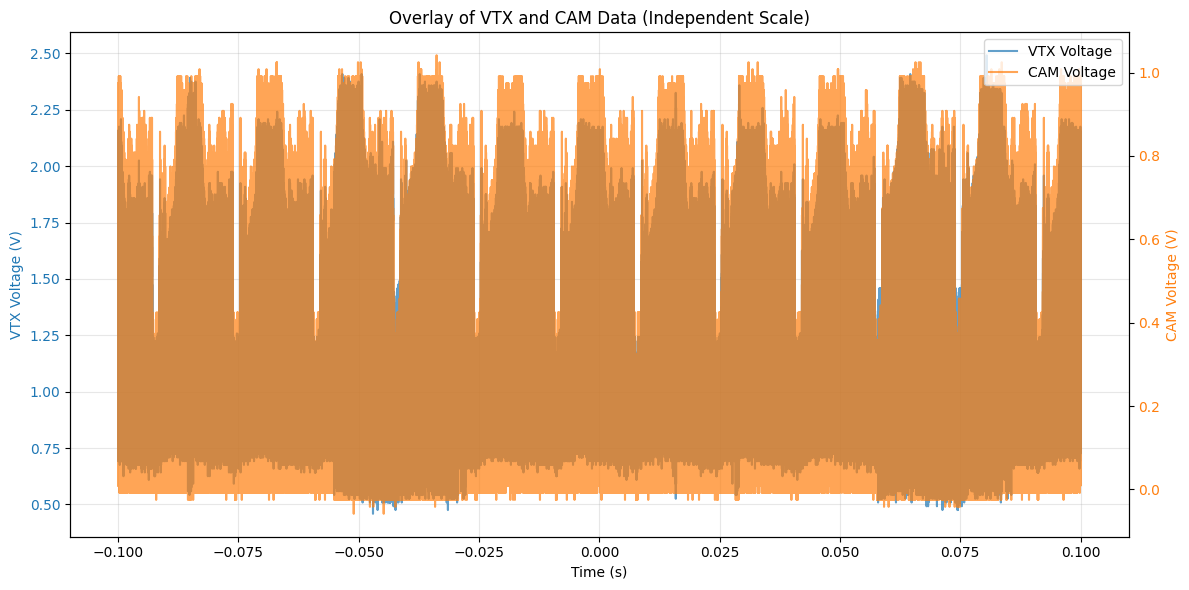

In [5]:
idx = 5
plot_overlay_vtx(get_data(idx)[0], get_data(idx)[1])

Сигнал vtx має різні значення gain, що ймовірно пов'язано з роботою AGC(Automatic Gain Control), тому для оцінки SNR варто використовувати windowing normalization. Тоді як сигнал camera має статичні offset та gain

In [9]:
def normalize_by_window(data, window_size=100000):
    df = data.copy()
    rolling = df['Value'].rolling(window=window_size, center=True, min_periods=1)
    
    rmin = rolling.min()
    rmax = rolling.max()
    
    diff = rmax - rmin
    df['Value'] = np.where(diff > 1e-9, (df['Value'] - rmin) / diff, 0)
    
    df['Value'] = df['Value'].fillna(0)
    
    return df

def normalize_by_sample(data, src_sample):    
    normalized = (data['Value'] - src_sample['Value'].min()) / (src_sample['Value'].max() - src_sample['Value'].min())
    data['Value'] = normalized
    return data


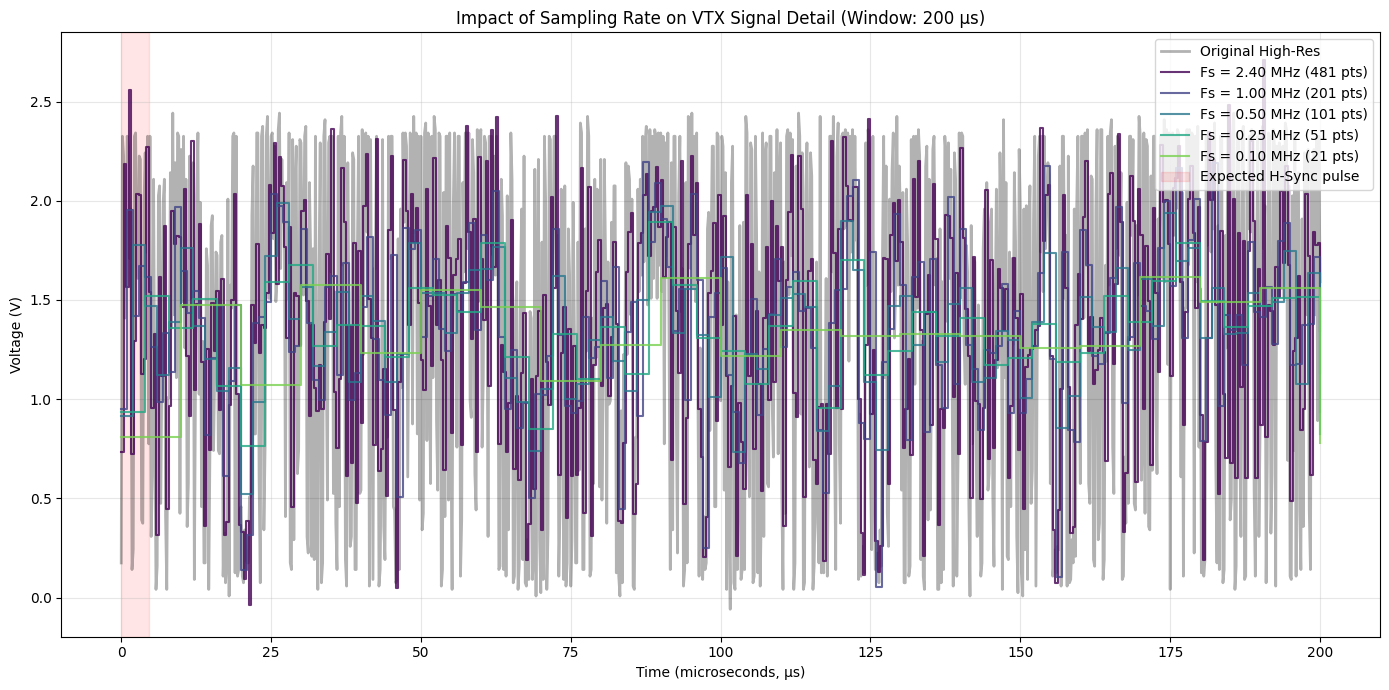

In [10]:
def apply_downsampling(df, target_fs=2.4e9):
    # Розрахунок поточної частоти
    dt = df['Second'].iloc[1] - df['Second'].iloc[0]
    current_fs = 1 / dt
    
    if current_fs <= target_fs:
        return df

    # Знаходимо раціональне відношення для ресемплінгу
    # limit_denominator(100) достатньо для точності, щоб не перевантажити RAM
    frac = Fraction(int(target_fs), int(current_fs)).limit_denominator(100)
    up, down = frac.numerator, frac.denominator

    # resample_poly автоматично застосовує анти-аліасинг фільтр (Kaiser window)
    resampled_v = signal.resample_poly(df['Value'].values, up, down)
    
    # Створюємо новий часовий ряд
    num_samples = len(resampled_v)
    new_time = np.linspace(df['Second'].iloc[0], df['Second'].iloc[-1], num_samples)
    
    return pd.DataFrame({'Second': new_time, 'Value': resampled_v})

def plot_sample_rate(vrx_data, sample_rates: list, duration: float = 128e-6):
    plt.figure(figsize=(14, 7))
    
    # 1. Відсікаємо потрібний проміжок часу від оригіналу
    start_time = vrx_data['Second'].iloc[0]
    mask = vrx_data['Second'] <= (start_time + duration)
    original_segment = vrx_data[mask]
    
    # Малюємо оригінал (якщо він має вищу частоту) для референсу
    plt.plot((original_segment['Second'] - start_time) * 1e6, 
             original_segment['Value'], 
             label='Original High-Res', color='black', alpha=0.3, lw=2)

    # 2. Проходимо по кожній цільовій частоті
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(sample_rates)))
    
    for i, fs in enumerate(sorted(sample_rates, reverse=True)):
        # Використовуємо вашу функцію downsampling
        resampled_df = apply_downsampling(original_segment, target_fs=fs)
        
        # Будуємо графік
        label = f"Fs = {fs/1e6:.2f} MHz ({len(resampled_df)} pts)"
        plt.step((resampled_df['Second'] - start_time) * 1e6, 
                 resampled_df['Value'], 
                 where='post', color=colors[i], label=label, alpha=0.8)

    # Оформлення
    plt.title(f"Impact of Sampling Rate on VTX Signal Detail (Window: {duration*1e6:.0f} µs)")
    plt.xlabel("Time (microseconds, µs)")
    plt.ylabel("Voltage (V)")
    
    # Підсвічуємо область H-Sync (зазвичай близько 4.7 µs)
    plt.axvspan(0, 4.7, color='red', alpha=0.1, label='Expected H-Sync pulse')
    
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Приклад виклику для вашого аналізу:
plot_sample_rate(get_data(24)[0], [2.4e6, 1e6, 500e3, 250e3, 100e3], duration=0.0002)

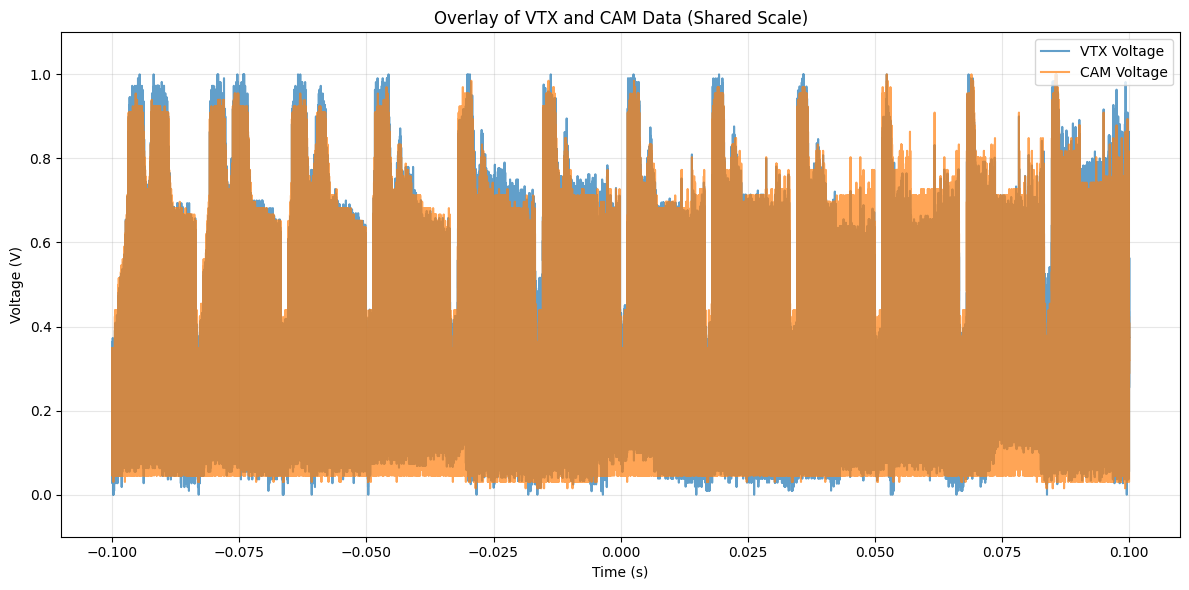

In [7]:
idx = 8
src_idx = 5
plot_overlay_vtx(vtx_data = normalize_by_window(get_data(idx)[0]), 
                 cam_data = normalize_by_sample(get_data(idx)[1], get_data(src_idx)[1]), 
                 shared_y = True)

Для оцінки варто порахувати SNR

In [ ]:
def calculate_snr(vtx, camera):
    start_time = max(vtx['Second'].min(), camera['Second'].min())
    end_time = min(vtx['Second'].max(), camera['Second'].max())
    
    vtx_sync = vtx[(vtx['Second'] >= start_time) & (vtx['Second'] <= end_time)]
    cam_sync = camera[(camera['Second'] >= start_time) & (camera['Second'] <= end_time)]
    
    min_len = min(len(vtx_sync), len(cam_sync))
    s_vtx = vtx_sync['Value'].values[:min_len]
    s_ref = cam_sync['Value'].values[:min_len]
    
    if np.any(np.isnan(s_vtx)) or np.any(np.isnan(s_ref)):
        return np.nan

    noise = s_vtx - s_ref
    p_signal = np.mean(s_ref**2)
    p_noise = np.mean(noise**2)
    
    if p_noise <= 1e-12: return 100.0
    return 10 * np.log10(p_signal / p_noise)

In [9]:
snr_results = []

print(f"{'Index':<10} | {'SNR (dB)':<10} | {'SNR Window (dB)':<15}")
print("-" * 25)

for idx in range(5, 30):
    try:
        raw_vtx, raw_camera = get_data(idx)

        vtx_norm = normalize_by_window(raw_vtx)
        camera_norm = normalize_by_sample(raw_camera, get_data(src_idx)[1]) 
        camera_norm_window = normalize_by_window(raw_camera)
        
        snr_value = calculate_snr(vtx_norm, camera_norm)
        snr_window = calculate_snr(vtx_norm, camera_norm_window)
        
        snr_results.append({"Index": idx, "SNR_dB": round(snr_value, 2), "SNR_Window_dB": round(snr_window, 2)})
        print(f"{idx:<10} | {snr_value:>8.2f} dB | {snr_window:>8.2f} dB")
        
    except FileNotFoundError:
        print(f"{idx:<10} | File missing")
    except Exception as e:
        print(f"{idx:<10} | Error: {e}")

df_snr = pd.DataFrame(snr_results)

Index      | SNR (dB)   | SNR Window (dB)
-------------------------
5          |    15.31 dB |    14.96 dB
6          |    14.25 dB |    13.92 dB
7          |    15.42 dB |    14.86 dB
8          |    15.19 dB |    14.84 dB
9          |    15.05 dB |    14.61 dB
10         |     1.58 dB |    13.60 dB
11         |    11.61 dB |    14.94 dB
12         |    12.37 dB |    12.41 dB
13         |     9.53 dB |     9.20 dB
14         |     4.78 dB |     4.59 dB
15         |    12.08 dB |    11.57 dB
16         |     0.66 dB |     5.67 dB
17         |     7.66 dB |     8.32 dB
18         |     5.92 dB |     5.39 dB
19         |     6.68 dB |     6.72 dB
20         |     5.24 dB |     5.45 dB
21         |     4.58 dB |     4.49 dB
22         |     4.27 dB |     4.33 dB
23         |     3.04 dB |     3.45 dB
24         |     3.43 dB |     3.30 dB
25         |   -18.67 dB |     2.09 dB
26         |   -18.60 dB |     2.26 dB
27         |   -18.50 dB |     1.97 dB
28         |   -19.09 dB |     2.27

Методи аналізу:
гістограма

In [11]:
def compute_autocorrelation(signal_df, max_lag_seconds=0.0001):
    y = signal_df['Value'].values
    y = y - np.mean(y)

    dt = signal_df['Second'].iloc[1] - signal_df['Second'].iloc[0]
    fs = 1 / dt
    max_lags = min(int(max_lag_seconds * fs), len(y) - 1)

    corr = signal.correlate(y, y, mode='full', method='auto')
    
    center = len(y) - 1
    autocorr = corr[center : center + max_lags]

    if autocorr[0] != 0:
        autocorr = autocorr / autocorr[0]
        
    lags_time = np.arange(max_lags) * dt
    return lags_time, autocorr

def plot_autocorr(lags_time, autocorr, idx):
    plt.figure(figsize=(10, 4))
    plt.plot(lags_time * 1e6, autocorr, color='tab:orange')
    plt.title(f"Autocorrelation - Sample {idx}")
    plt.xlabel("Lag (microseconds, µs)")
    plt.ylabel("Correlation Coefficient")
    plt.grid(True, alpha=0.3)
    
    plt.axvline(x=63.56, color='red', linestyle='--', alpha=0.5, label='NTSC H-Sync (63.56µs)')
    plt.legend()
    plt.show()

def print_max_autocorr(lags_time, autocorr):
    mask = lags_time > 10e-6 
    if not np.any(mask):
        print("Сигнал занадто короткий для аналізу.")
        return
    
    masked_autocorr = autocorr[mask]
    masked_lags = lags_time[mask]
    
    max_val = np.max(masked_autocorr)
    max_lag = masked_lags[np.argmax(masked_autocorr)]
    
    print(f"--- Результат аналізу періодичності ---")
    print(f"Найвищий коефіцієнт кореляції: {max_val:.4f}")
    print(f"Зміщення піку (Lag): {max_lag * 1e6:.2f} µs")
    
    if 60 <= max_lag * 1e6 <= 68:
        print("СТАТУС: Виявлено структуру відеосигналу (H-Sync OK)")
    else:
        print("СТАТУС: Структура відеосигналу не виявлена (Шум/Інше)")

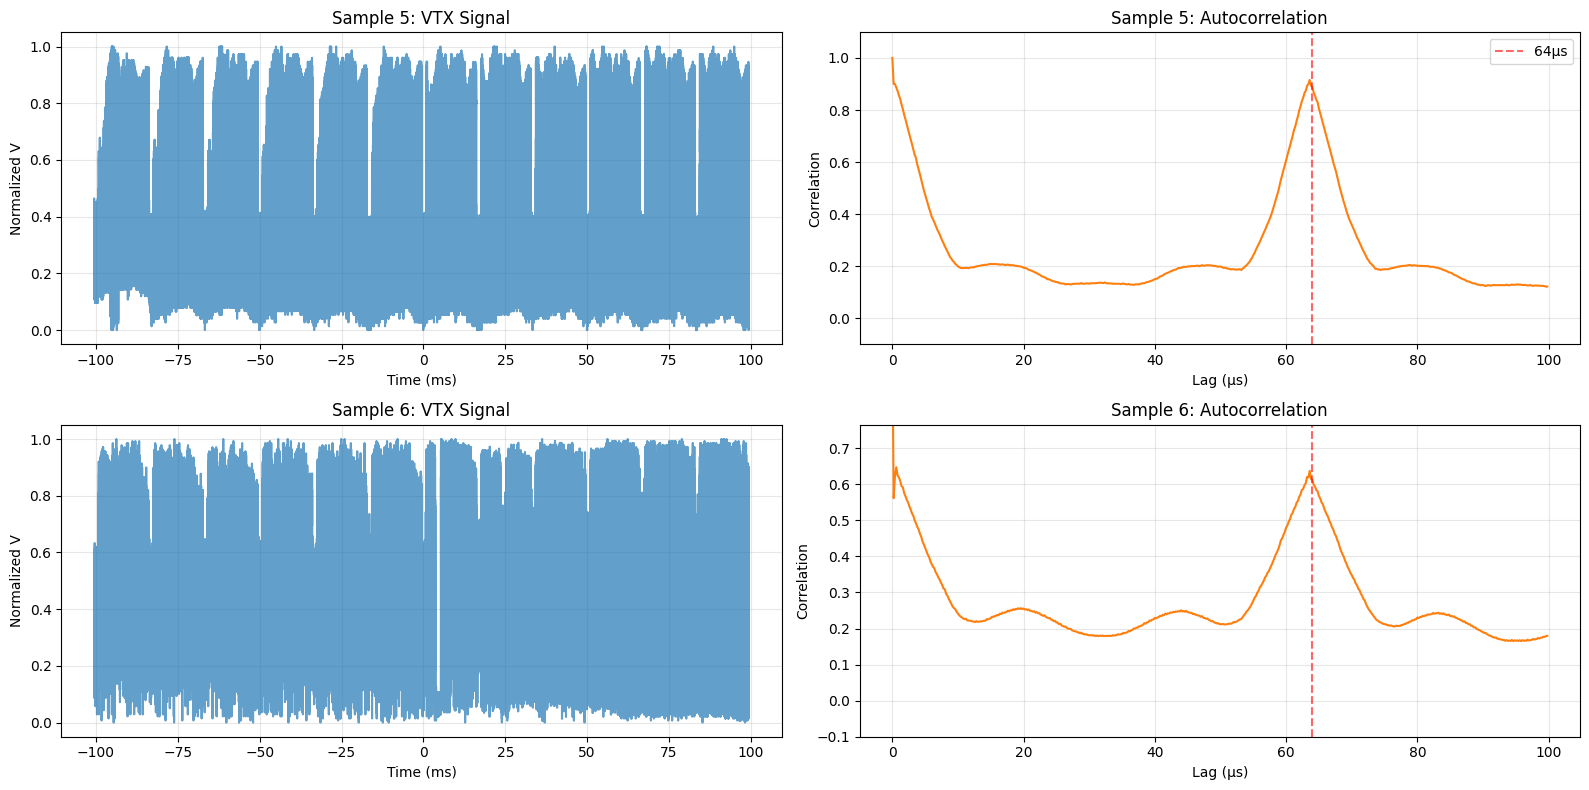

In [13]:
def plot_grid_analysis(indices=range(5, 30)):
    n_rows = len(indices)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows))
    
    for i, idx in enumerate(indices):
        try:
            # 1. Отримання та підготовка даних
            raw_vtx, _ = get_data(idx)
            # Для візуалізації сигналу використовуємо віконну нормалізацію
            vtx_norm = normalize_by_window(raw_vtx)
            
            # 2. Розрахунок автокореляції
            lags_t, corr_v = compute_autocorrelation(raw_vtx, max_lag_seconds=100e-6)
            
            # --- Ліва колонка: Сигнал VTX ---
            ax_sig = axes[i, 0]
            ax_sig.plot(vtx_norm['Second'] * 1e3, vtx_norm['Value'], color='tab:blue', alpha=0.7)
            ax_sig.set_title(f"Sample {idx}: VTX Signal")
            ax_sig.set_ylabel("Normalized V")
            ax_sig.set_xlabel("Time (ms)")
            ax_sig.grid(True, alpha=0.3)

            # --- Права колонка: Автокореляція ---
            ax_corr = axes[i, 1]
            lags_us = lags_t * 1e6
            ax_corr.plot(lags_us, corr_v, color='tab:orange')
            ax_corr.axvline(x=64, color='red', linestyle='--', alpha=0.6, label='64µs')
            
            # Масштабуємо Y для правої колонки (ігноруючи пік при 0)
            mask = lags_us > 10
            if any(mask):
                y_max = max(0.2, np.max(corr_v[mask]) * 1.2)
                ax_corr.set_ylim(-0.1, min(1.1, y_max))
            
            ax_corr.set_title(f"Sample {idx}: Autocorrelation")
            ax_corr.set_xlabel("Lag (µs)")
            ax_corr.set_ylabel("Correlation")
            ax_corr.grid(True, alpha=0.3)
            if i == 0: ax_corr.legend()

        except Exception as e:
            axes[i, 0].text(0.5, 0.5, f"Error loading {idx}: {e}", ha='center')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Виклик функції
plot_grid_analysis([5,6])

In [ ]:
def plot_grid_analysis_with_resample(indices=range(5, 30)):
    n_rows = len(indices)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    
    for i, idx in enumerate(indices):
        try:
            # 1. Завантаження даних
            raw_vtx, _ = get_data(idx)
            
            # 2. DOWN-SAMPLING ДО 2.4 GHz
            vtx_resampled = apply_downsampling(raw_vtx, target_fs=2.4e9)
            
            # 3. Обчислення автокореляції на ресемпльованих даних
            lags_t, corr_v = compute_autocorrelation(vtx_resampled, max_lag_seconds=100e-6)
            
            # Для візуалізації сигналу зліва
            vtx_plot = normalize_by_window(vtx_resampled)

            # --- Колонка 1: Сигнал (Resampled 2.4GHz) ---
            ax_sig = axes[i, 0]
            ax_sig.plot(vtx_plot['Second'] * 1e3, vtx_plot['Value'], color='tab:blue', alpha=0.6)
            ax_sig.set_title(f"Sample {idx}: VTX Signal (2.4GHz Downsampled)")
            ax_sig.grid(True, alpha=0.2)

            # --- Колонка 2: Автокореляція ---
            ax_corr = axes[i, 1]
            lags_us = lags_t * 1e6
            ax_corr.plot(lags_us, corr_v, color='tab:orange')
            ax_corr.axvline(x=64, color='red', linestyle='--', alpha=0.6)
            
            # Масштабування
            mask = lags_us > 10
            if any(mask):
                y_max = max(0.2, np.max(corr_v[mask]) * 1.3)
                ax_corr.set_ylim(-0.1, min(1.1, y_max))
            
            ax_corr.set_title(f"Sample {idx}: Autocorrelation (Resampled)")
            ax_corr.grid(True, alpha=0.2)

        except Exception as e:
            axes[i, 0].text(0.5, 0.5, f"Error: {e}", ha='center')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

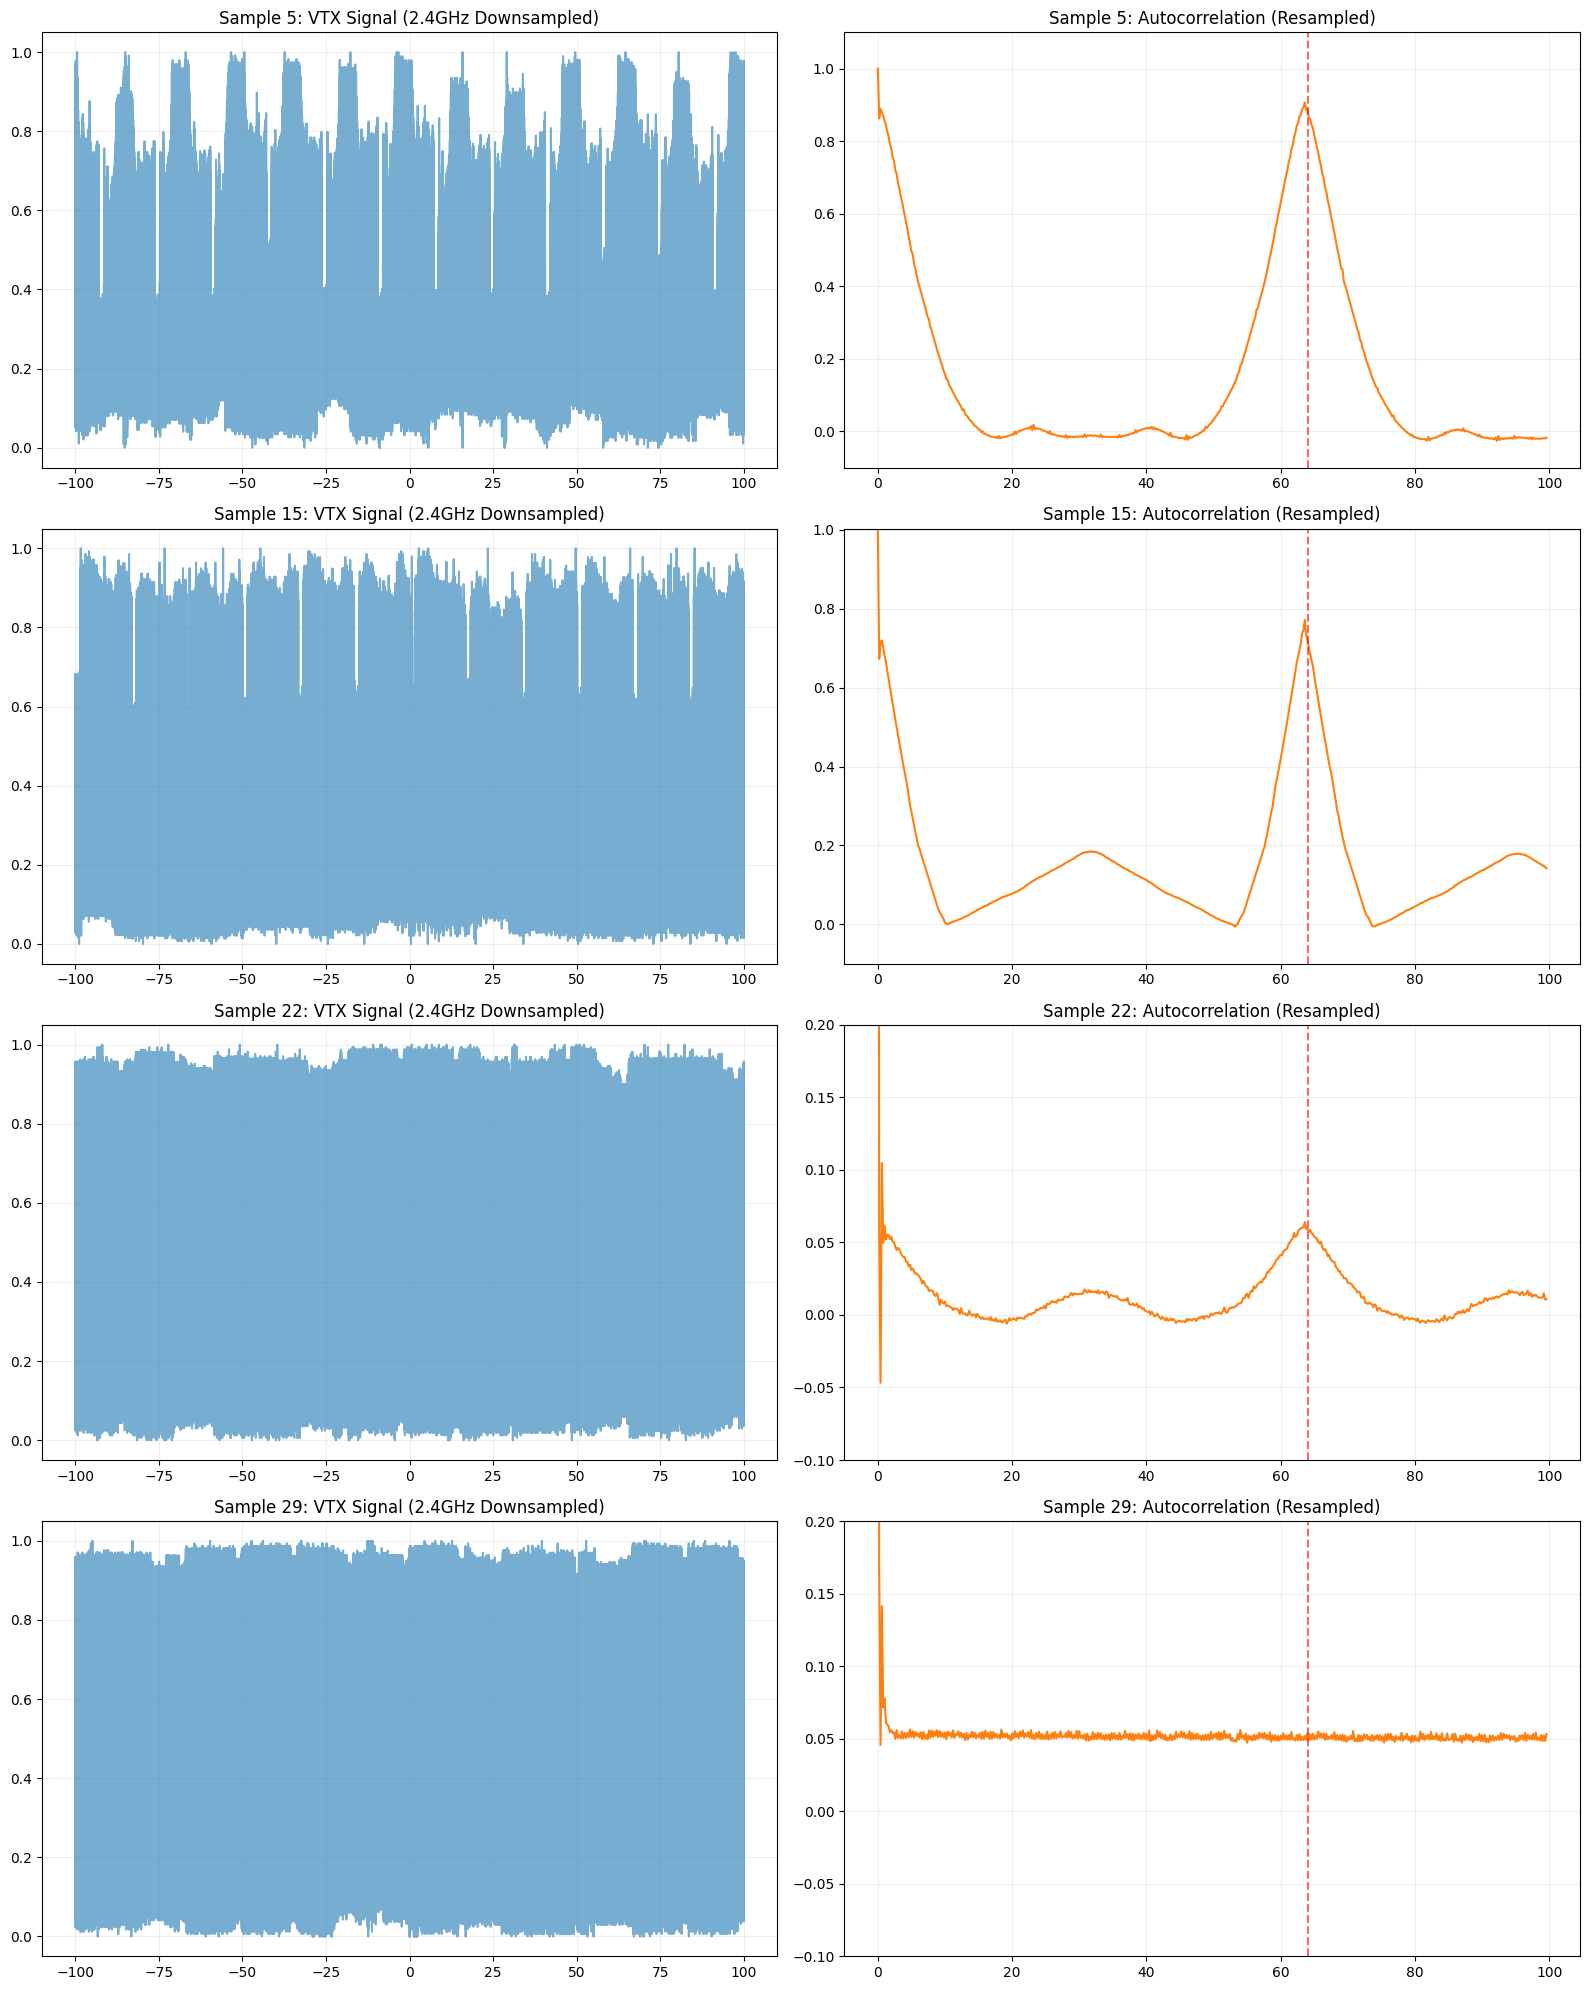

In [13]:
plot_grid_analysis_with_resample([5, 15, 22, 29])

In [14]:
def plot_autocor_length_grid(idx: int, time_dist: list[float]):
    """
    Будує сітку графіків: ліва колонка - фрагмент сигналу, 
    права колонка - його автокореляція.
    """
    # Сортуємо від найкоротшого до найдовшого для логіки дослідження
    time_dist = sorted(time_dist)
    n_rows = len(time_dist)
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows))
    
    try:
        # 1. Завантаження даних
        raw_vtx, _ = get_data(idx)
        # Ресемплінг до 2 MHz для реалістичності (ESP32)
        df_resampled = apply_downsampling(raw_vtx, target_fs=2.4e6)
        
        for i, duration in enumerate(time_dist):
            # 2. Виділення фрагмента [0; duration]
            start_time = df_resampled['Second'].iloc[0]
            mask = df_resampled['Second'] <= (start_time + duration)
            signal_part = df_resampled[mask]
            
            if signal_part.empty:
                continue

            # --- Ліва колонка: Сигнал у часі ---
            ax_sig = axes[i, 0]
            ax_sig.plot((signal_part['Second'] - start_time) * 1e3, signal_part['Value'], 
                        color='tab:blue', linewidth=0.5)
            ax_sig.set_title(f"Signal Fragment: {duration / 64e-6:.0f} lines")
            ax_sig.set_ylabel("Voltage (V)")
            ax_sig.set_xlabel("Time (ms)")
            ax_sig.grid(True, alpha=0.2)

            # --- Права колонка: Автокореляція ---
            lags_t, corr_v = compute_autocorrelation(signal_part, max_lag_seconds=100e-6)
            lags_us = lags_t * 1e6
            
            ax_corr = axes[i, 1]
            ax_corr.plot(lags_us, corr_v, color='tab:orange')
            ax_corr.axvline(x=64, color='red', linestyle='--', alpha=0.6)
            
            # # Масштабування осі Y для видимості піку (ігноруємо lag=0)
            # mask_zoom = lags_us > 10
            # if any(mask_zoom):
            #     y_max = max(0.2, np.max(corr_v[mask_zoom]) * 1.3)
            #     ax_corr.set_ylim(-0.1, min(1.1, y_max))
            
            ax_corr.set_title(f"Autocorr (N={len(signal_part)} samples)")
            ax_corr.set_xlabel("Lag (µs)")
            ax_corr.set_ylabel("Correlation")
            ax_corr.grid(True, alpha=0.2)

        plt.suptitle(f"Sample {idx}: Analysis of Signal Length Impact", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()

    except Exception as e:
        print(f"Error building length grid: {e}")


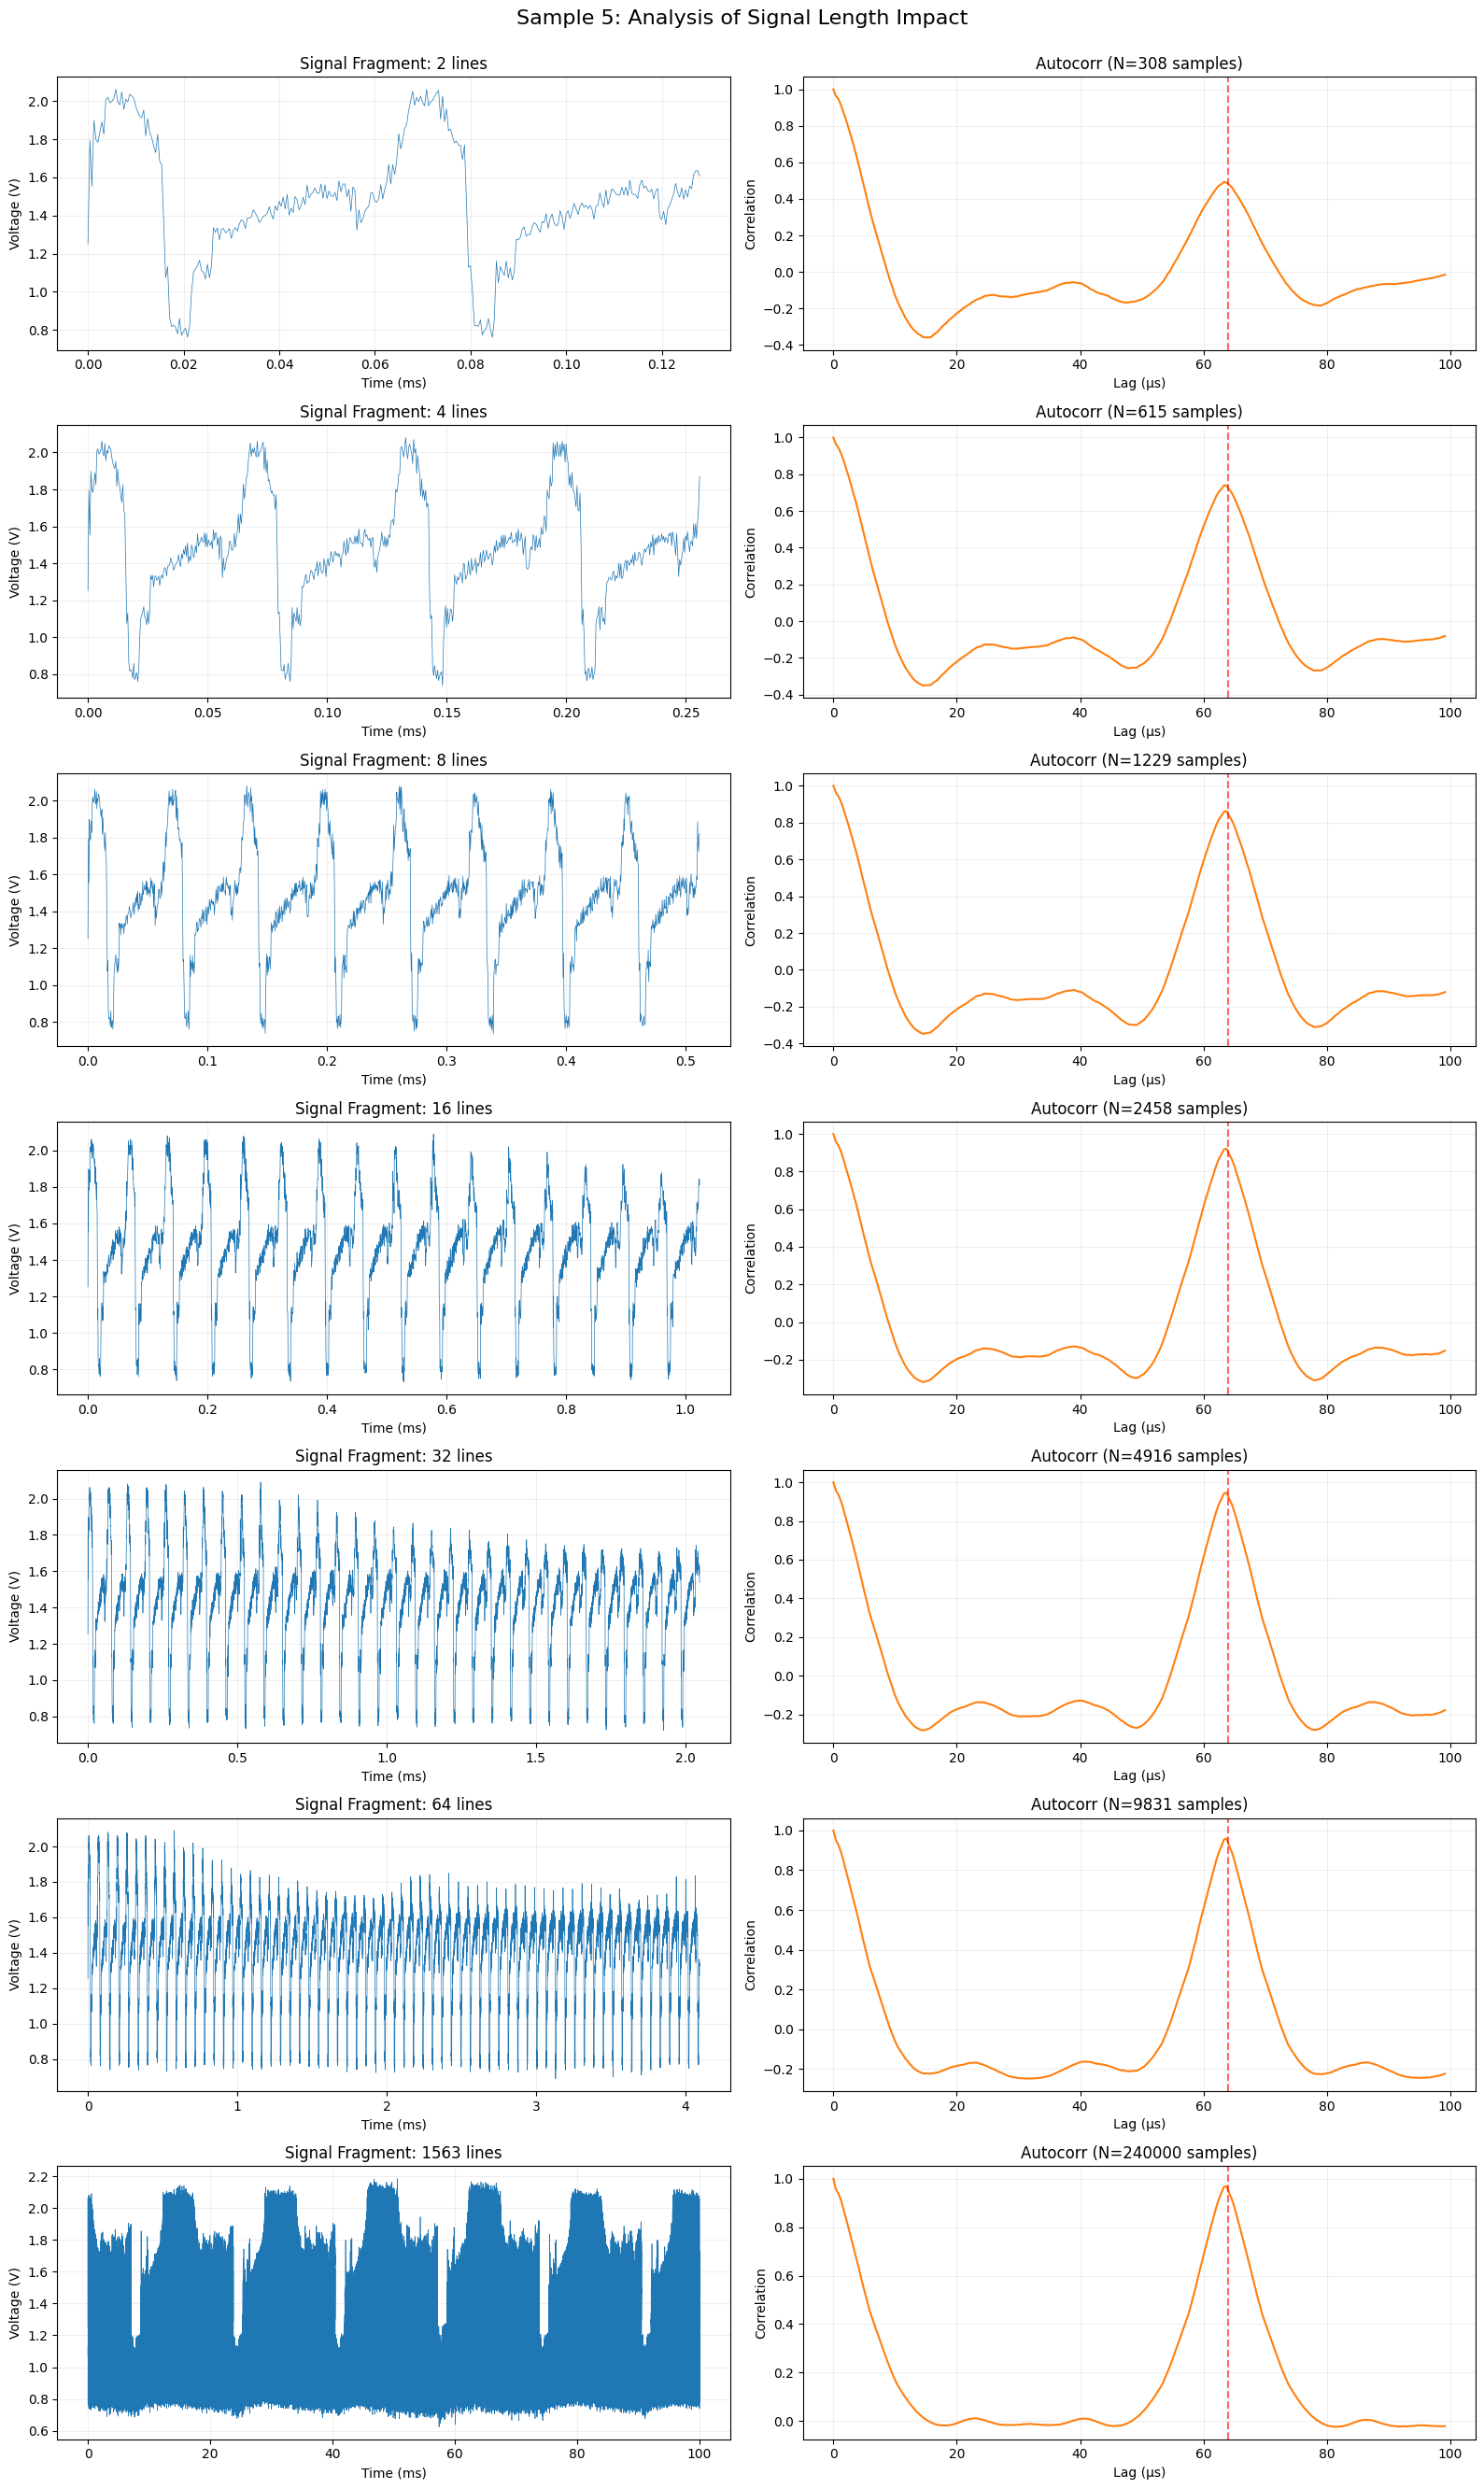

In [15]:
plot_autocor_length_grid(idx=5, time_dist=[128e-6, 256e-6, 512e-6, 1024e-6, 2048e-6, 4096e-6, 1e-1])

FFT

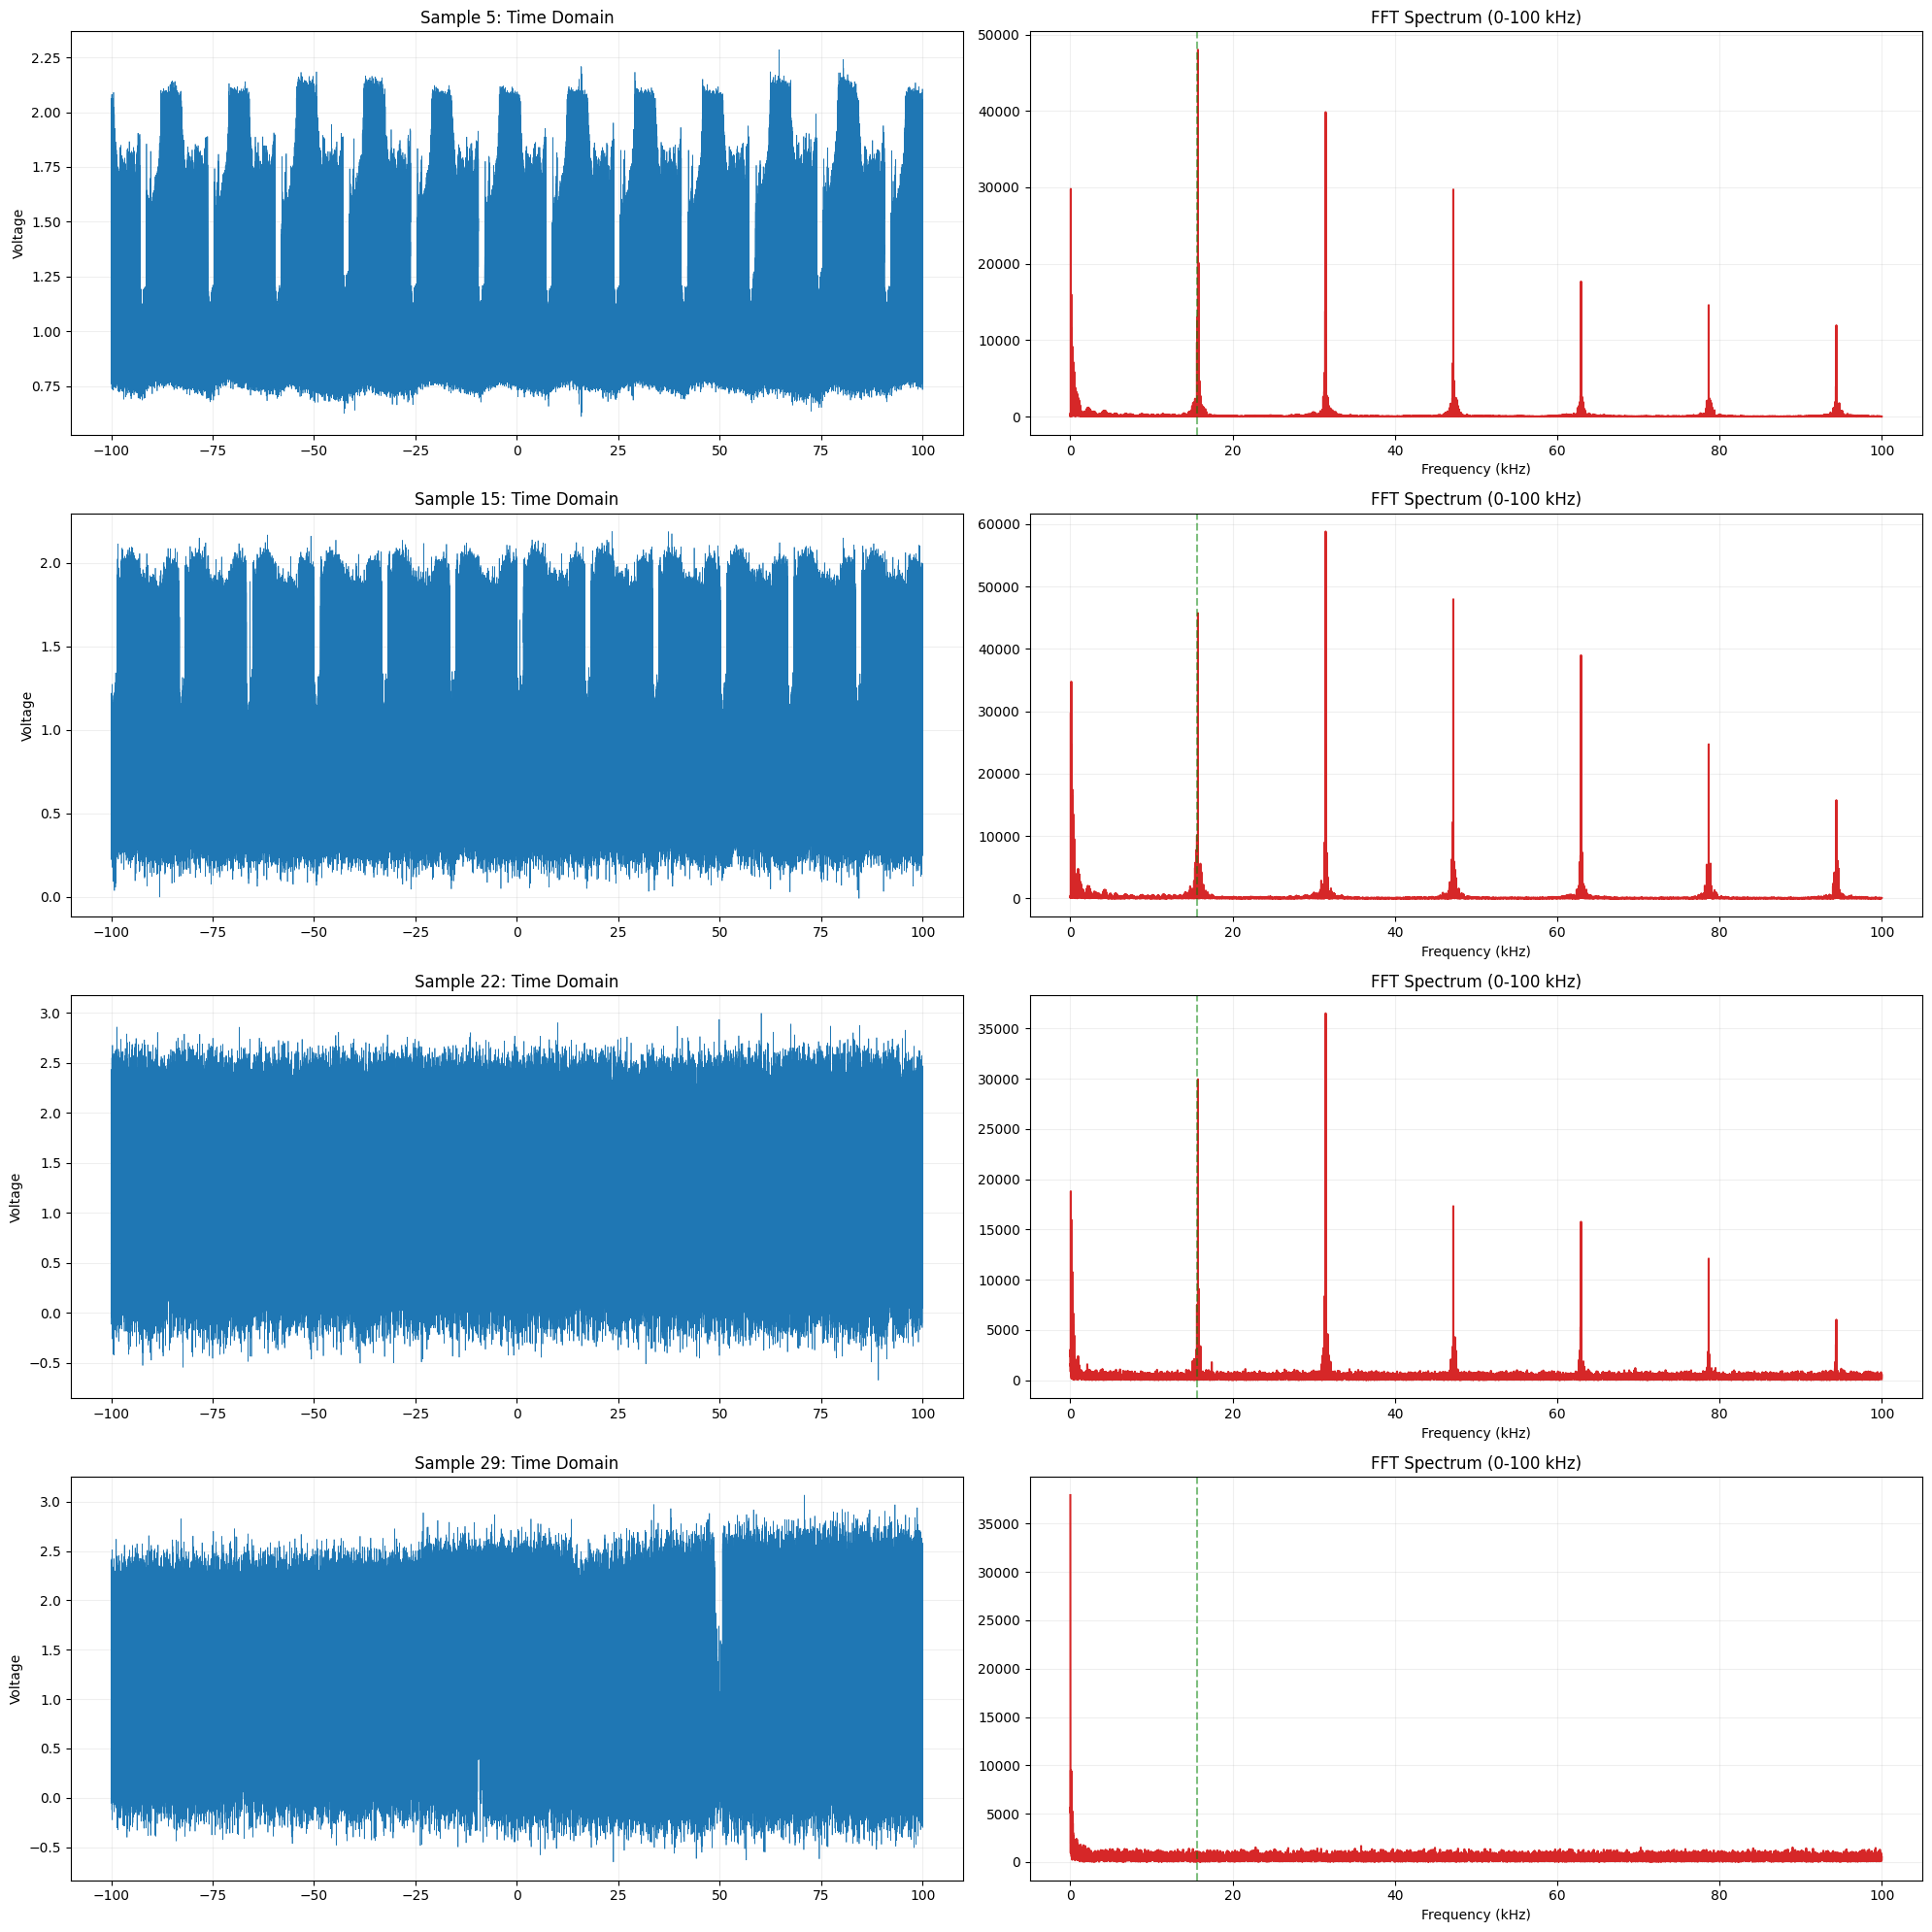

In [16]:
from scipy.fft import fft, fftfreq

def plot_comprehensive_analysis(indices=range(5, 30)):
    n_rows = len(indices)
    # Створюємо сітку: n_rows рядків, 3 колонки
    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))
    
    for i, idx in enumerate(indices):
        try:
            # 1. Отримання та ресемплінг (симулюємо реальний вхід АЦП)
            raw_data, _ = get_data(idx)
            # Ресемплимо до 2 MHz (реальна межа ESP32), щоб аналіз був чесним
            df = apply_downsampling(raw_data, target_fs=2.4e6)
            
            y = df['Value'].values - np.mean(df['Value'].values) # центруємо
            fs = 1 / (df['Second'].iloc[1] - df['Second'].iloc[0])
            n = len(y)

            # --- КОЛОНКА 1: СИГНАЛ (Часова область) ---
            axes[i, 0].plot(df['Second'] * 1e3, df['Value'], color='tab:blue', linewidth=0.5)
            axes[i, 0].set_title(f"Sample {idx}: Time Domain")
            axes[i, 0].set_ylabel("Voltage")
            axes[i, 0].grid(True, alpha=0.2)

            # --- КОЛОНКА 2: FFT (Частотна область) ---
            # Рахуємо амплітудний спектр
            yf = fft(y)
            xf = fftfreq(n, 1/fs)
            
            # Беремо лише позитивні частоти до 100 кГц (де живуть гармоніки H-Sync)
            mask_fft = (xf > 0) & (xf < 100000)
            axes[i, 1].plot(xf[mask_fft] / 1e3, np.abs(yf[mask_fft]), color='tab:red')
            # Позначимо першу гармоніку PAL (15.625 kHz)
            axes[i, 1].axvline(x=15.625, color='green', linestyle='--', alpha=0.5)
            axes[i, 1].set_title("FFT Spectrum (0-100 kHz)")
            axes[i, 1].set_xlabel("Frequency (kHz)")
            axes[i, 1].grid(True, alpha=0.2)


        except Exception as e:
            axes[i, 0].text(0.5, 0.5, f"Error: {e}", ha='center')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

plot_comprehensive_analysis([5, 15, 22, 29])

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def plot_fft_length_grid(idx: int, time_dist: list[float]):
    """
    Будує сітку графіків: ліва колонка - фрагмент сигналу, 
    права колонка - його спектр FFT.
    """
    # Сортуємо від найкоротшого до найдовшого
    time_dist = sorted(time_dist)
    n_rows = len(time_dist)
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows))
    
    try:
        # 1. Завантаження даних
        raw_data, _ = get_data(idx)
        # Ресемплінг до частоти ESP32 (наприклад, 2 MHz) для коректного порівняння
        df_resampled = apply_downsampling(raw_data, target_fs=2e6)
        
        for i, duration in enumerate(time_dist):
            # 2. Виділення фрагмента [0; duration]
            start_time = df_resampled['Second'].iloc[0]
            mask = df_resampled['Second'] <= (start_time + duration)
            df_part = df_resampled[mask]
            
            if len(df_part) < 2:
                continue

            y = df_part['Value'].values - np.mean(df_part['Value'].values)
            fs = 1 / (df_resampled['Second'].iloc[1] - df_resampled['Second'].iloc[0])
            n = len(y)

            # --- Ліва колонка: Сигнал у часі ---
            ax_sig = axes[i, 0]
            ax_sig.plot((df_part['Second'] - start_time) * 1e3, df_part['Value'], 
                        color='tab:blue', linewidth=0.5)
            ax_sig.set_title(f"Signal: {duration/64e-6:.0f} lines")
            ax_sig.set_ylabel("Voltage (V)")
            ax_sig.set_xlabel("Time (ms)")
            ax_sig.grid(True, alpha=0.2)

            # --- Права колонка: FFT спектр ---
            yf = fft(y)
            xf = fftfreq(n, 1/fs)
            
            # Маска для позитивних частот до 100 кГц
            mask_f = (xf > 0) & (xf < 2400000)
            
            # Нормалізація амплітуди на n для порівняння різних довжин
            amplitude = np.abs(yf[mask_f]) / n
            
            ax_fft = axes[i, 1]
            ax_fft.plot(xf[mask_f] / 1e3, amplitude, color='tab:red')
            
            # Позначка PAL H-Sync частоти (15.625 kHz)
            ax_fft.axvline(x=15.625, color='green', linestyle='--', alpha=0.4, label='15.625 kHz')
            ax_fft.axvline(x=15.625*2, color='green', linestyle='--', alpha=0.4, label='15.625 kHz harmonica')
            
            ax_fft.set_title(f"FFT (N={n} samples)")
            ax_fft.set_xlabel("Frequency (kHz)")
            ax_fft.set_ylabel("Amplitude")
            ax_fft.set_xlim(0, 40) # Зосереджуємося на перших гармоніках
            ax_fft.set_yscale('log') # Логарифмічна шкала для виявлення піків у шумі
            ax_fft.grid(True, which="both", ls="-", alpha=0.2)
            if i == 0: ax_fft.legend()

        plt.suptitle(f"Sample {idx}: FFT Resolution vs Signal Length", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()

    except Exception as e:
        print(f"Error building FFT length grid: {e}")

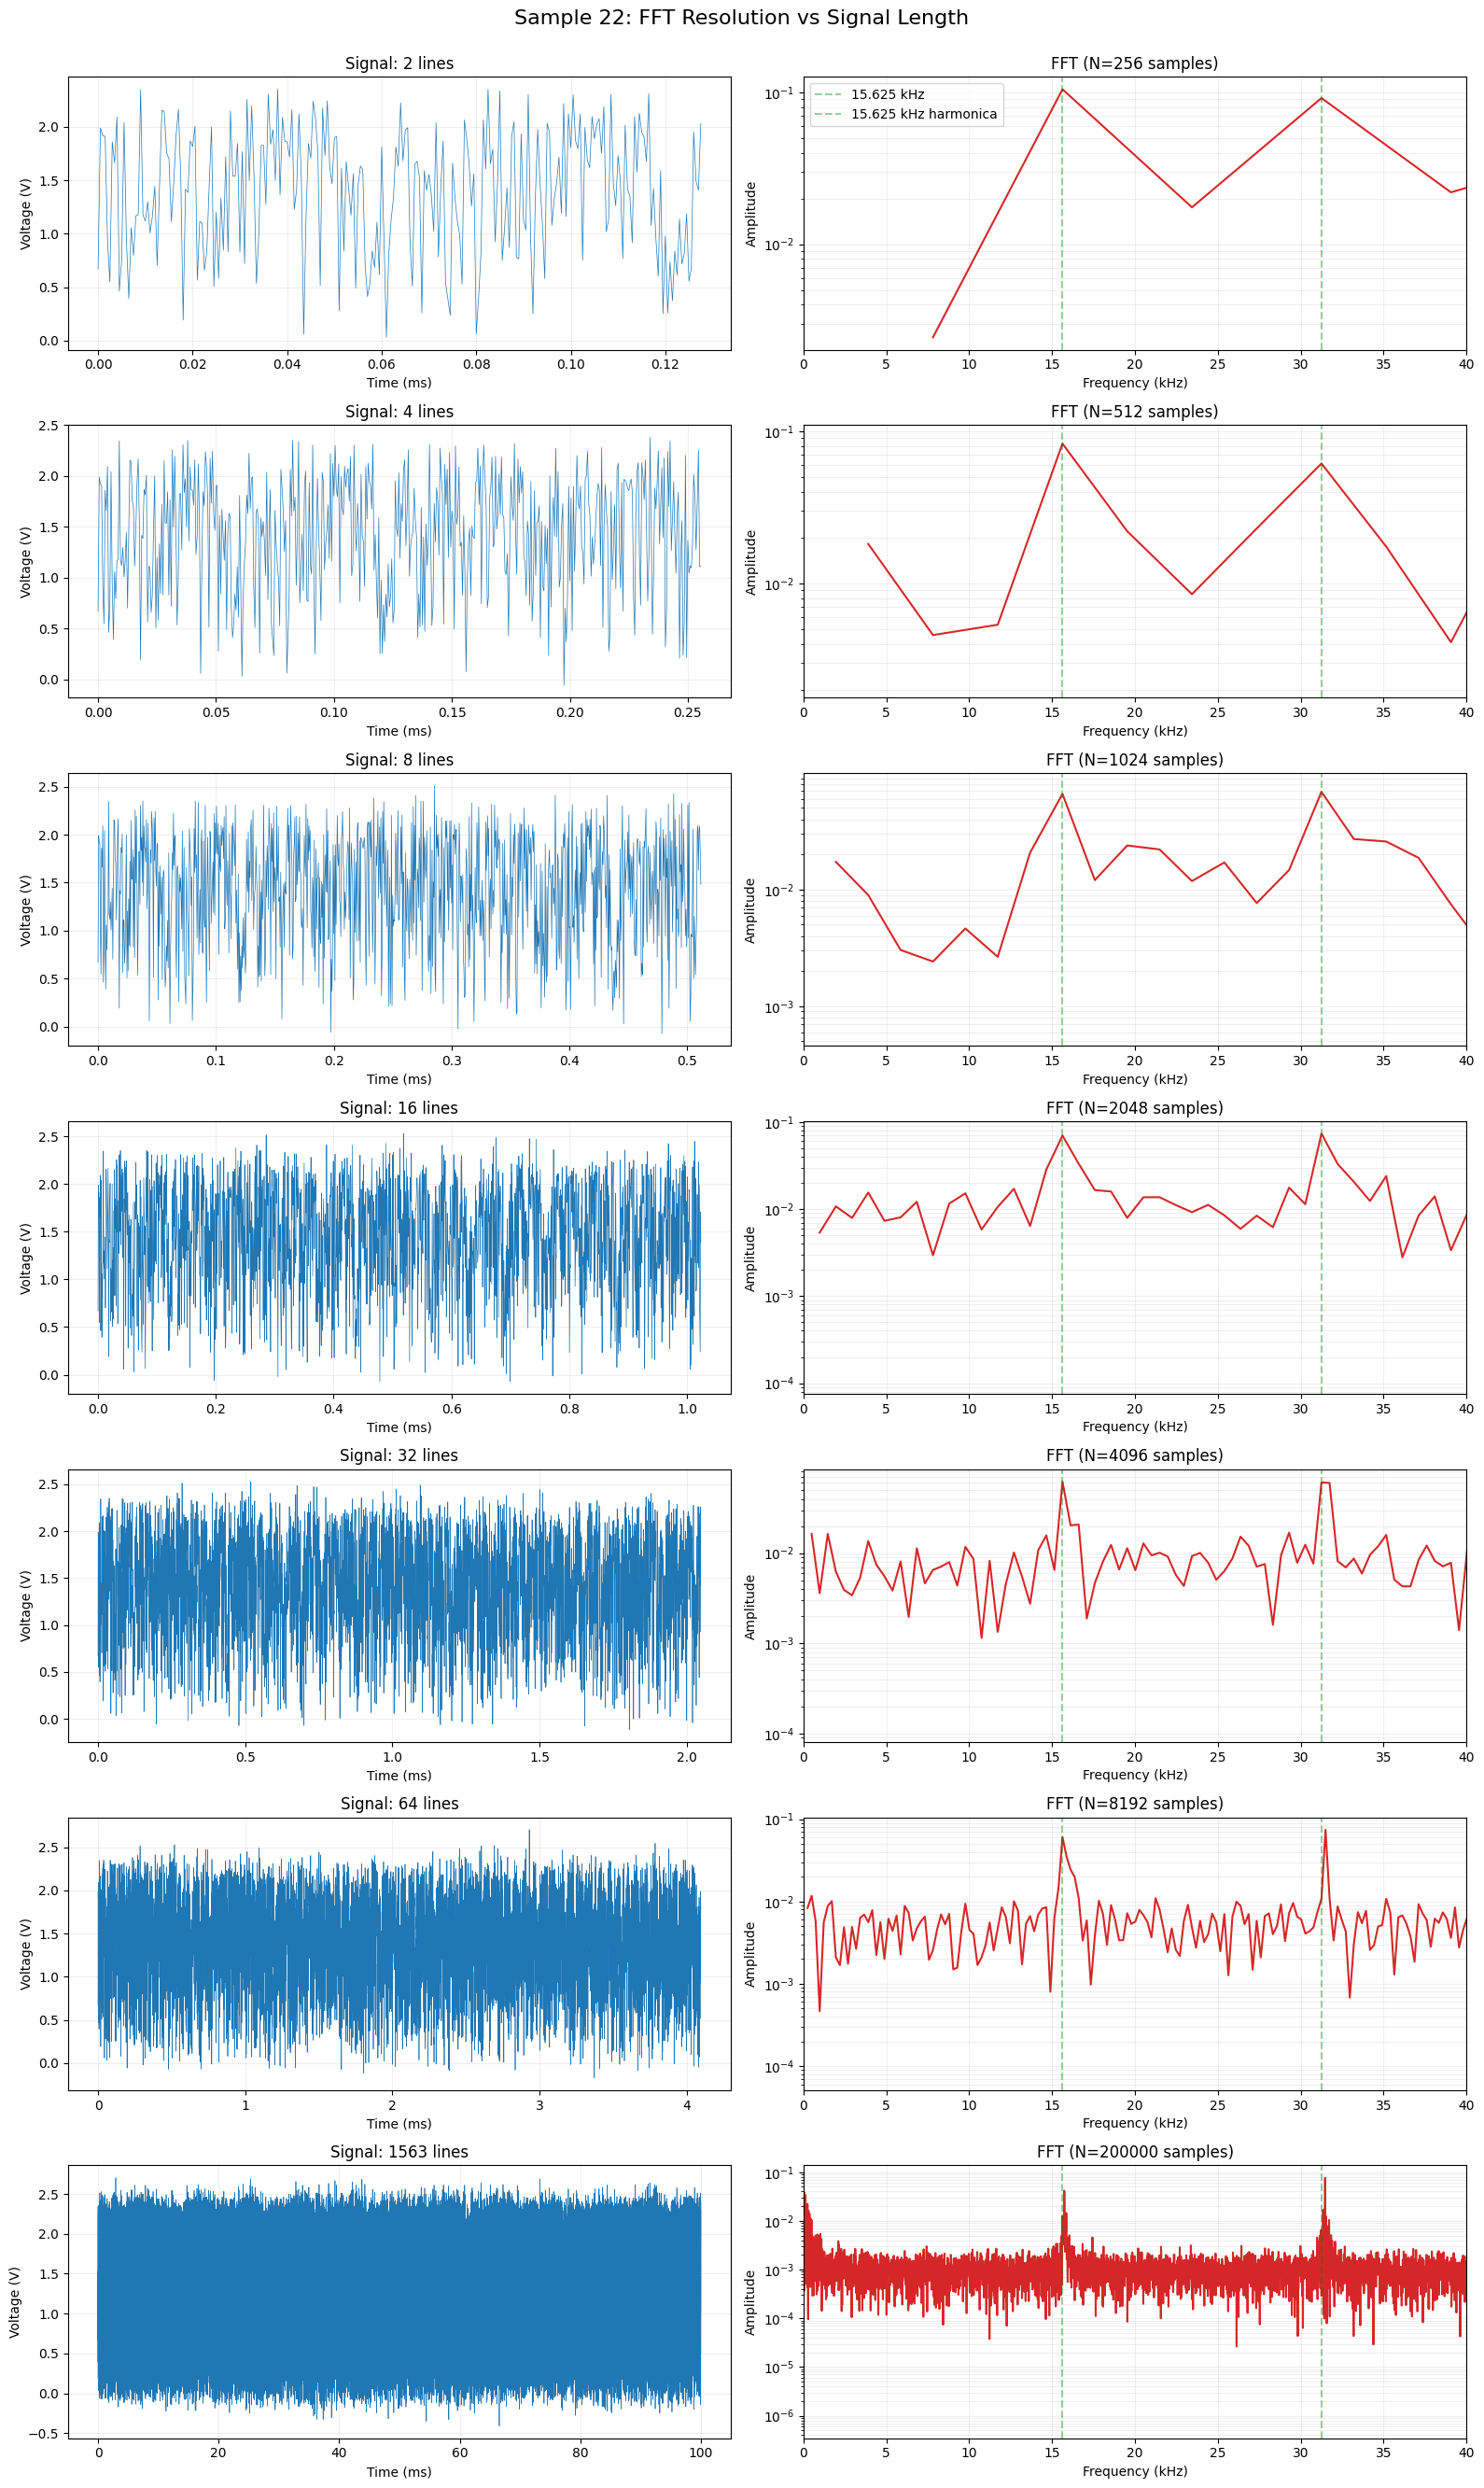

In [18]:
plot_fft_length_grid(idx=22, time_dist=[128e-6, 256e-6, 512e-6, 1024e-6, 2048e-6, 4096e-6, 1e-1])